In [1]:
import pandas as pd
from pathlib import Path
import geopandas as gpd
import numpy as np
import h3
from shapely.geometry import Polygon, Point
import matplotlib.pyplot as plt
import mapclassify
from shapely import Polygon
import shapely
import contextily
from shapely.geometry import box
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import plotly.express as px
import seaborn as sns

In [2]:
NOTEBOOK_PATH = Path().resolve()
DATA_DIR = NOTEBOOK_PATH / 'data'
MAPS_DIR = NOTEBOOK_PATH / "maps"
ASSETS_DIR =  NOTEBOOK_PATH / "assets"
MAPS_DIR.mkdir(exist_ok=True)
ASSETS_DIR.mkdir(exist_ok=True)

In [3]:
mobility_gdf = gpd.read_file(DATA_DIR / "erasmus_mobility_datasets.gpkg", layer='2018_student_mobility_NUTS2')
mobility_gdf.head()

,OD_ID,ORIGIN,DESTINATION,geometry
0,AL01_DE94,AL01,DE94,"LINESTRING (5147813.725 2147741.583, 4171381.1..."
1,AL01_DE94,AL01,DE94,"LINESTRING (5147813.725 2147741.583, 4171381.1..."
2,AL01_ITG2,AL01,ITG2,"LINESTRING (5147813.725 2147741.583, 4237843.6..."
3,AL02_AT31,AL02,AT31,"LINESTRING (5166646.306 2059058.198, 4616056.5..."
4,AL02_DE12,AL02,DE12,"LINESTRING (5166646.306 2059058.198, 4224282.2..."


In [4]:
europe_gdf = gpd.read_file(DATA_DIR / "europe_borders.zip").to_crs(mobility_gdf.crs)
europe_gdf.head()

,GID_0,COUNTRY,geometry
0,ALB,Albania,"MULTIPOLYGON (((5185353.594 1901653.12, 518399..."
1,BEL,Belgium,"MULTIPOLYGON (((3992762.882 2941912.743, 39926..."
2,BGR,Bulgaria,"MULTIPOLYGON (((5583297.05 2151545.861, 558324..."
3,HRV,Croatia,"MULTIPOLYGON (((4878690.154 2207591.579, 48787..."
4,CYP,Cyprus,"MULTIPOLYGON (((6466798.95 1664346.442, 646742..."


In [5]:
starts = gpd.GeoDataFrame(mobility_gdf.copy(), geometry=mobility_gdf.geometry.apply(lambda g: Point(g.coords[0])))
ends   = gpd.GeoDataFrame(mobility_gdf.copy(), geometry=mobility_gdf.geometry.apply(lambda g: Point(g.coords[-1])))

starts_in = gpd.sjoin(starts, europe_gdf, predicate="within")
ends_in   = gpd.sjoin(ends, europe_gdf, predicate="within")

valid_ids = set(starts_in.index) & set(ends_in.index)

mobility_europe = mobility_gdf.loc[list(valid_ids)]

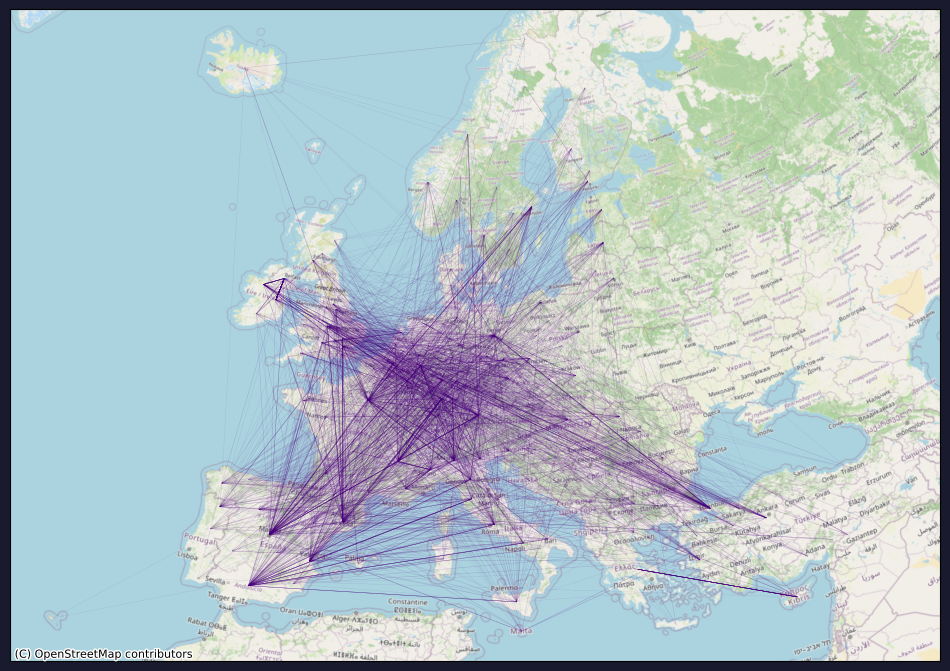

In [ ]:
fig, ax = plt.subplots(figsize=(12, 13), facecolor='#1a1a2e')

ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel('')
ax.set_ylabel('')

mobility_europe.plot(ax = ax, color="indigo", linewidth=0.3, alpha=0.1)

contextily.add_basemap(
    ax,
    source=contextily.providers.OpenStreetMap.Mapnik,
    crs=mobility_europe.crs,
    zoom=5,
    alpha=1
)

# plt.savefig(ASSETS_DIR / "exploratory_map.png", dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

### Lengths

In [6]:
mobility_europe["length_km"] = mobility_europe.geometry.length / 1000

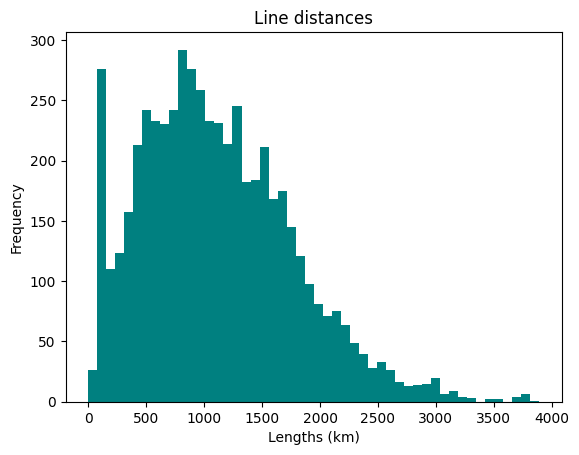

In [ ]:
plt.hist(mobility_europe["length_km"], color="teal", bins=50)
plt.xlabel("Lengths (km)")
plt.ylabel("Frequency")
plt.title("Line distances")

# plt.savefig(ASSETS_DIR / "distances_hist.png", dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

In [7]:
fig = px.histogram(mobility_europe,
                   x='length_km',
                   nbins=50, 
                   color_discrete_sequence=['teal'])  

fig.update_traces(
    hovertemplate='Lengths: %{x} km<br>Count: %{y}<extra></extra>'
)

fig.update_layout(
    xaxis_title='Lengths (km)',
    yaxis_title='Frequency',
    bargap=0.2, 
    title=dict(
        text="Line Distances",
        x=0.5,
        font=dict(size=24)
    ),
    dragmode=False,
    xaxis_fixedrange=True,
    yaxis_fixedrange=True,
    paper_bgcolor="whitesmoke"
)

fig.show(config={"displayModeBar": False})
# fig.write_html(ASSETS_DIR / "distances_interactive_hist.html", config={"displayModeBar": False})

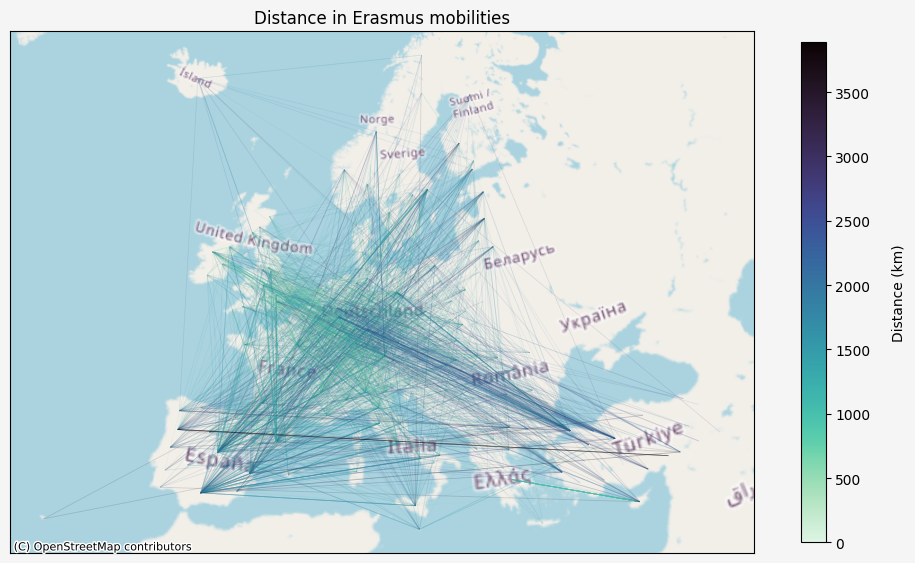

In [ ]:
fig, ax = plt.subplots(figsize=(12, 13), facecolor='whitesmoke')

ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel('')
ax.set_ylabel('')

vals = mobility_europe["length_km"]
vals = vals.clip(lower=1e-6)
vmin, vmax = vals.min(), vals.max()
alphas = 0.05 + (vals - vmin) / (vmax - vmin) * (0.15 - 0.05)

norm = (vals - vals.min()) / (vals.max() - vals.min())
lw = 0.1 + (norm ** 0.2) * (0.6 - 0.1) 

mobility_europe.plot(
    ax = ax,
    column="length_km",
    cmap=sns.color_palette("mako_r", as_cmap=True),
    linewidth=lw,
    alpha=alphas,
    legend=True,
    legend_kwds={ "shrink": 0.5}
)
cbar = ax.get_figure().axes[-1]
cbar.set_ylabel("Distance (km)", rotation=90, labelpad=15)

contextily.add_basemap(
    ax,
    source=contextily.providers.OpenStreetMap.Mapnik,
    crs=mobility_europe.crs,
    zoom=3,
    alpha=1
)

plt.title("Distance in Erasmus mobilities")
# plt.savefig(MAPS_DIR / "distances_km.png", dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

### Countries

In [8]:

mobility_europe["origin_point"]      = mobility_europe.geometry.apply(lambda l: Point(l.coords[0]))
mobility_europe["destination_point"] = mobility_europe.geometry.apply(lambda l: Point(l.coords[-1]))

origin_gdf = gpd.GeoDataFrame(mobility_europe[["OD_ID"]], geometry=mobility_europe["origin_point"], crs=mobility_europe.crs)
dest_gdf   = gpd.GeoDataFrame(mobility_europe[["OD_ID"]], geometry=mobility_europe["destination_point"], crs=mobility_europe.crs)

origin_joined = gpd.sjoin(origin_gdf, europe_gdf[["COUNTRY", "geometry"]], how="left", predicate="within")
dest_joined   = gpd.sjoin(dest_gdf,   europe_gdf[["COUNTRY", "geometry"]], how="left", predicate="within")

origin_countries = origin_joined[~origin_joined.index.duplicated(keep="first")]["COUNTRY"].reindex(mobility_europe.index)
dest_countries   = dest_joined[~dest_joined.index.duplicated(keep="first")]["COUNTRY"].reindex(mobility_europe.index)

mobility_europe["origin_country"]      = origin_countries.values
mobility_europe["destination_country"] = dest_countries.values
mobility_europe.head()

,OD_ID,ORIGIN,DESTINATION,geometry,length_km,origin_point,destination_point,origin_country,destination_country
0,AL01_DE94,AL01,DE94,"LINESTRING (5147813.725 2147741.583, 4171381.1...",1523.202437,POINT (5147813.725 2147741.583),POINT (4171381.181 3316811.792),Albania,Germany
1,AL01_DE94,AL01,DE94,"LINESTRING (5147813.725 2147741.583, 4171381.1...",1523.202437,POINT (5147813.725 2147741.583),POINT (4171381.181 3316811.792),Albania,Germany
2,AL01_ITG2,AL01,ITG2,"LINESTRING (5147813.725 2147741.583, 4237843.6...",946.252729,POINT (5147813.725 2147741.583),POINT (4237843.643 1888225.346),Albania,Italy
4,AL02_DE12,AL02,DE12,"LINESTRING (5166646.306 2059058.198, 4224282.2...",1249.425540,POINT (5166646.306 2059058.198),POINT (4224282.254 2879432.609),Albania,Germany
5,AL02_DE40,AL02,DE40,"LINESTRING (5166646.306 2059058.198, 4552249.1...",1355.720574,POINT (5166646.306 2059058.198),POINT (4552249.195 3267567.39),Albania,Germany


In [ ]:
import plotly.graph_objects as go

country_counts = mobility_europe["origin_country"].value_counts().reset_index()
country_counts.columns = ["country", "count"]
total = country_counts["count"].sum()

top15 = country_counts.head(15).copy()
others = country_counts.iloc[15:].copy()

other_row = pd.DataFrame([{
    "country": "Other",
    "count": others["count"].sum(),
}])
other_countries_list = "<br>".join(others["country"].tolist()) 

final = pd.concat([top15, other_row], ignore_index=True) 
final["pct"] = (final["count"] / total * 100).round(2)

hover = []
for _, row in final.iterrows():
    if row["country"] == "Other":
        hover.append(
            f"<b>Other countries</b><br>"
            f"Students: {int(row['count'])}<br>"
            f"Share: {row['pct']}%<br><br>"
            f"<i>{other_countries_list}</i>"
        )
    else:
        hover.append(
            f"<b>{row['country']}</b><br>"
            f"Students: {int(row['count'])}<br>"
            f"Share: {row['pct']}%"
        )
        
viridis = px.colors.get_colorscale("Viridis")
greens = px.colors.sample_colorscale("Viridis", [i/16 for i in range(16)], colortype="rgb")

fig = go.Figure(go.Pie(
    labels=final["country"],
    values=final["count"],
    hovertemplate="%{customdata}<extra></extra>",
    customdata=hover,
    textinfo="none",
    hole=0.3,
    sort=False,
    marker=dict(colors=greens),
    rotation=-29, 
    direction="clockwise"
))

fig.update_layout(
    title=dict(text="Erasmus Mobility by Origin Country", x=0.5, xanchor="center", font=dict(size=28, family="Georgia")),
    legend=dict(orientation="v", x=1.05, y=0.5, font=dict(size=16)),
    hoverlabel=dict(bgcolor="white", font_size=16, namelength=-1),
    width=900,
    height=700,
    modebar=dict(remove=["all"]),
    paper_bgcolor="whitesmoke",
)

fig.show()
# fig.write_html(ASSETS_DIR / "origin_country_pie.html", config={"displayModeBar": False})

In [11]:
import plotly.graph_objects as go

country_counts = mobility_europe["destination_country"].value_counts().reset_index()
country_counts.columns = ["country", "count"]
total = country_counts["count"].sum()

top15 = country_counts.head(15).copy()
others = country_counts.iloc[15:].copy()

other_row = pd.DataFrame([{
    "country": "Other",
    "count": others["count"].sum(),
}])
other_countries_list = "<br>".join(others["country"].tolist()) 

final = pd.concat([top15, other_row], ignore_index=True) 
final["pct"] = (final["count"] / total * 100).round(2)

hover = []
for _, row in final.iterrows():
    if row["country"] == "Other":
        hover.append(
            f"<b>Other countries</b><br>"
            f"Students: {int(row['count'])}<br>"
            f"Share: {row['pct']}%<br><br>"
            f"<i>{other_countries_list}</i>"
        )
    else:
        hover.append(
            f"<b>{row['country']}</b><br>"
            f"Students: {int(row['count'])}<br>"
            f"Share: {row['pct']}%"
        )
        
viridis = px.colors.get_colorscale("Viridis")
greens = px.colors.sample_colorscale("Viridis", [i/16 for i in range(16)], colortype="rgb")

fig = go.Figure(go.Pie(
    labels=final["country"],
    values=final["count"],
    hovertemplate="%{customdata}<extra></extra>",
    customdata=hover,
    textinfo="none",
    hole=0.3,
    sort=False,
    marker=dict(colors=greens),
    rotation=-56, 
    direction="clockwise"
))

fig.update_layout(
    title=dict(text="Erasmus Mobility by Destination Country", x=0.5, xanchor="center", font=dict(size=28, family="Georgia")),
    legend=dict(orientation="v", x=1.05, y=0.5, font=dict(size=16)),
    hoverlabel=dict(bgcolor="white", font_size=16, namelength=-1),
    width=900,
    height=700,
    modebar=dict(remove=["all"]),
    paper_bgcolor="whitesmoke",
)

fig.show()
# fig.write_html(ASSETS_DIR / "destination_country_pie.html", config={"displayModeBar": False})

In [13]:
origin_counts = mobility_europe.groupby("origin_country").size().rename("outgoing")
dest_counts   = mobility_europe.groupby("destination_country").size().rename("incoming")
total_counts  = (origin_counts.add(dest_counts, fill_value=0)).rename("total").astype(int)

stats = pd.DataFrame({"outgoing": origin_counts, "incoming": dest_counts, "total": total_counts}).fillna(0).astype(int).reset_index()
stats.columns = ["country", "outgoing", "incoming", "total"]
stats["hover"] = stats.apply(
    lambda r: f"<b>{r['country']}</b><br>"
              f"Total: {r['total']:,} students<br>"
              f"Outgoing: {r['outgoing']:,}<br>"
              f"Incoming: {r['incoming']:,}",
    axis=1
)

In [14]:
fig = px.choropleth(
    stats,
    locations="country",
    locationmode="country names",
    color="total",
    hover_name=None,
    hover_data={"country": False, "total": False, "outgoing": False, "incoming": False},
    custom_data=["hover"],
    color_continuous_scale="Viridis_r",
    scope="europe",
)

fig.update_traces(hovertemplate="%{customdata[0]}<extra></extra>")

fig.add_trace(go.Choropleth(
    locations=["Germany"],
    locationmode="country names",
    z=[0],
    colorscale=[[0, "rgba(0,0,0,0)"], [1, "rgba(0,0,0,0)"]],
    showscale=False,
    marker=dict(line=dict(color="white", width=1.5)),
    hoverinfo="skip",
))

fig.update_layout(
    title=dict(text="Erasmus Mobilities by Country", x=0.45, y=0.98, xanchor="center", font=dict(size=28, family="Georgia")),
    coloraxis_colorbar=dict(title="Total"),
     geo=dict(
        scope="world",
        projection=dict(type="azimuthal equal area"),
        center=dict(lat=54, lon=15),
        bgcolor="#0f1f17",
        lakecolor="#0f1f17",
        landcolor="#1a3a2a",        
        showocean=True,
        oceancolor="#0f1f17",
        showframe=False,
        showcoastlines=True,
        coastlinecolor="#2d6a4f",
        lataxis=dict(range=[34, 76]),
        lonaxis=dict(range=[-25, 45]),
    ),
    paper_bgcolor="whitesmoke",
    font=dict(color="#0f1f17"),
    modebar=dict(remove=["all"]),
    margin=dict(l=0, r=0, t=50, b=30),
   autosize=True
)

fig.show(config={"displayModeBar": False})
# fig.write_html(MAPS_DIR / "country_mobilities.html", full_html=True, include_plotlyjs="cdn", config={"displayModeBar": False, "responsive": True})

/tmp/ipykernel_6513/2216133261.py:1: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


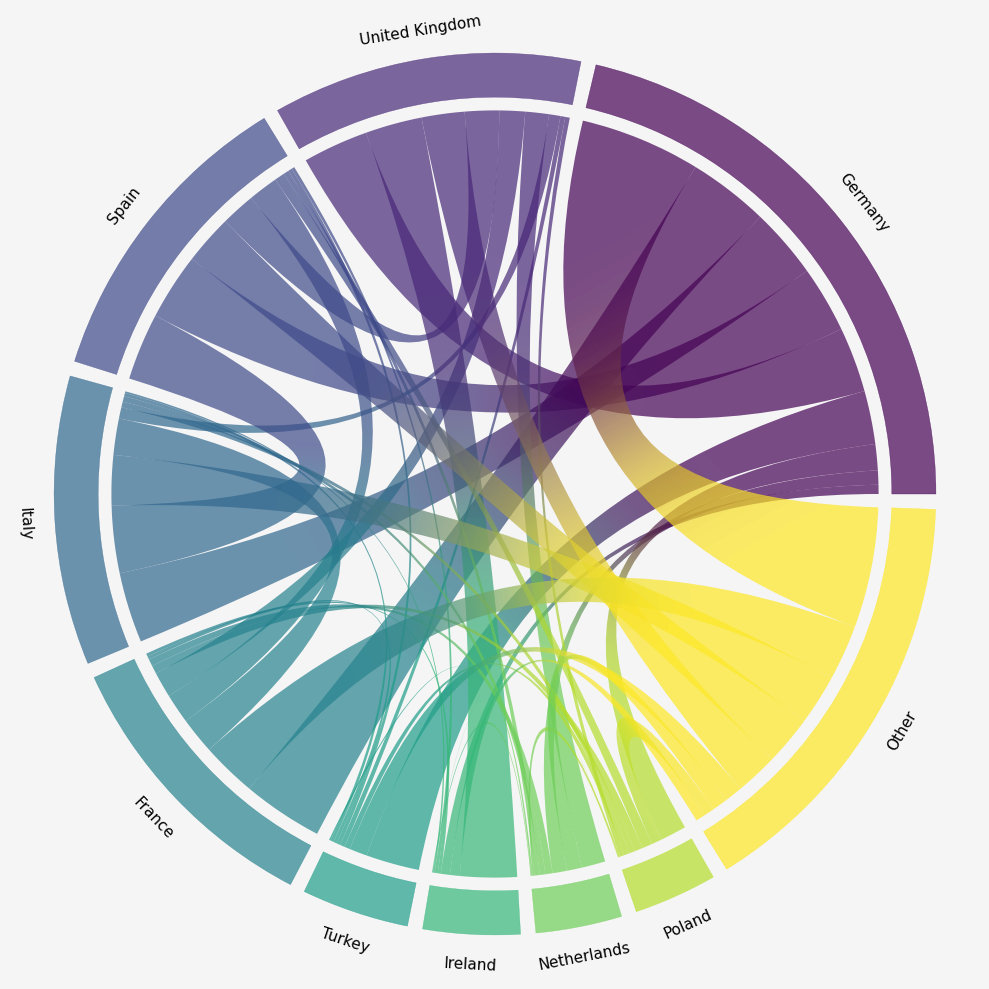

In [155]:
from mpl_chord_diagram import chord_diagram

top_n = 9
origin_counts = mobility_europe["origin_country"].value_counts()
dest_counts = mobility_europe["destination_country"].value_counts()
total_counts = origin_counts.add(dest_counts, fill_value=0).sort_values(ascending=False)

top_countries = total_counts.head(top_n).index.tolist()
all_countries = top_countries + ["Other"]

matrix = pd.DataFrame(0, index=all_countries, columns=all_countries)

for _, row in mobility_europe.iterrows():
    o = row["origin_country"] if row["origin_country"] in top_countries else "Other"
    d = row["destination_country"] if row["destination_country"] in top_countries else "Other"
    if o != d:
        matrix.loc[o, d] += 1
        matrix.loc[d, o] += 1 

fig, ax = plt.subplots(figsize=(10, 10))
chord_diagram(
    matrix.values.tolist(),
    all_countries,
    ax=ax,
    cmap="viridis",
    use_gradient=True,
    gap=0.03,
    fontsize=11,
)
fig.patch.set_facecolor("whitesmoke")
ax.set_facecolor("whitesmoke")
plt.tight_layout()
# plt.savefig(ASSETS_DIR / "mobilities_chord.png", dpi=300, bbox_inches="tight")
plt.show()

## Cartogram

In [46]:
# Count outgoing (origin) mobilities per country
outgoing = (
    mobility_europe
    .groupby("origin_country")
    .size()
    .reset_index(name="outgoing")
    .rename(columns={"origin_country": "country"})
)

# Count incoming (destination) mobilities per country
incoming = (
    mobility_europe
    .groupby("destination_country")
    .size()
    .reset_index(name="incoming")
    .rename(columns={"destination_country": "country"})
)

# Merge and compute total
countries_df = (
    outgoing
    .merge(incoming, on="country", how="outer")
    .fillna(0)
    .assign(
        outgoing=lambda x: x["outgoing"].astype(int),
        incoming=lambda x: x["incoming"].astype(int),
    )
)
countries_df["total"] = countries_df["outgoing"] + countries_df["incoming"]

# Join geometry from europe_boundaries
countries = gpd.GeoDataFrame(
    countries_df.merge(
        europe_gdf[["COUNTRY", "geometry"]],
        left_on="country",
        right_on="COUNTRY",
        how="left"
    ).drop(columns="COUNTRY"),
    geometry="geometry",
    crs=europe_gdf.crs,
)

countries = countries.drop_duplicates(subset="country").reset_index(drop=True)
countries.head()

,country,outgoing,incoming,total,geometry
0,Albania,16,2,18,"MULTIPOLYGON (((5185353.594 1901653.12, 518399..."
1,Belgium,76,219,295,"MULTIPOLYGON (((3992762.882 2941912.743, 39926..."
2,Bulgaria,37,63,100,"MULTIPOLYGON (((5583297.05 2151545.861, 558324..."
3,Croatia,38,29,67,"MULTIPOLYGON (((4878690.154 2207591.579, 48787..."
4,Cyprus,57,15,72,"MULTIPOLYGON (((6466798.95 1664346.442, 646742..."


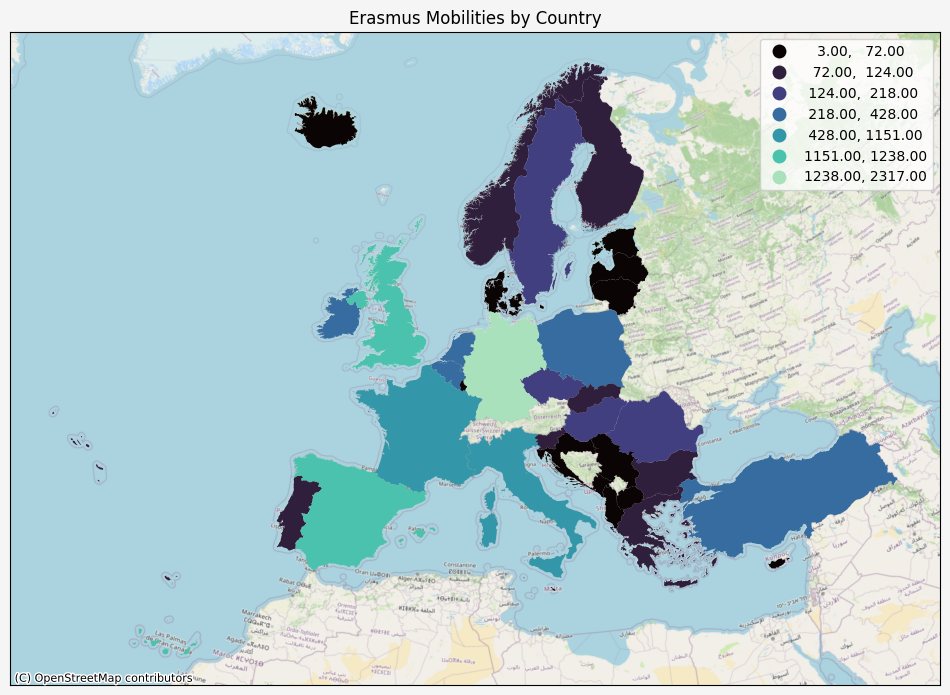

In [65]:
fig, ax = plt.subplots(figsize=(12, 13), facecolor='whitesmoke')

ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel('')
ax.set_ylabel('')

full_cmap = sns.color_palette("mako", as_cmap=True)
cmap = mcolors.LinearSegmentedColormap.from_list(
    "mako_truncated",
    full_cmap(np.linspace(0, 0.90, 256))
)

countries.plot(
    ax = ax,
    column="total",
    scheme="NaturalBreaks",
    k=7,
    cmap=cmap,
    linewidth=1,
    legend=True,
)

contextily.add_basemap(
    ax,
    source=contextily.providers.OpenStreetMap.Mapnik,
    crs=countries.crs,
    zoom=5,
    alpha=1
)

plt.title("Erasmus Mobilities by Country")
# plt.savefig(MAPS_DIR / "countries_mako2.png", dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

In [59]:
countries["total"].describe()

count      34.000000
mean      321.647059
std       505.727192
min         3.000000
25%        62.000000
50%       116.500000
75%       324.250000
max      2317.000000
Name: total, dtype: float64

In [61]:
countries.geometry.area.describe()

count    3.400000e+01
mean     1.661792e+11
std      1.891552e+11
min      3.233678e+08
25%      3.905141e+10
50%      7.853464e+10
75%      2.868738e+11
max      7.807043e+11
dtype: float64

In [63]:
import cartogram
countries["geometry"] = countries.geometry.simplify(1000) 
countries["total_scaled"] = countries["total"] * 1e4
c = cartogram.Cartogram(countries, "total_scaled", max_iterations=10)

In [ ]:
stadia_api = "secret"
stadia_url = f"https://tiles.stadiamaps.com/tiles/alidade_smooth_dark/{{z}}/{{x}}/{{y}}.png?api_key={stadia_api}"

In [77]:
import matplotlib.font_manager as fm
for path in Path(NOTEBOOK_PATH / "fonts/Josefin_Sans/static").glob("*.ttf"):
    fm.fontManager.addfont(str(path))

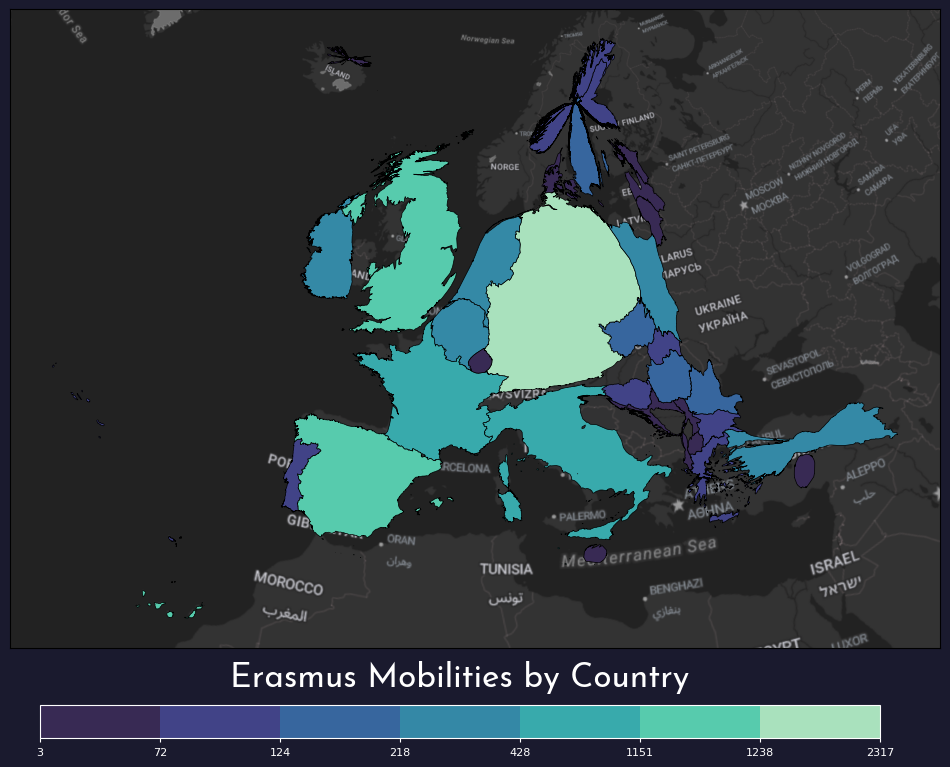

In [99]:
fig, ax = plt.subplots(figsize=(12, 13), facecolor='#1a1a2e')

ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel('')
ax.set_ylabel('')

full_cmap = sns.color_palette("mako", as_cmap=True)
cmap = mcolors.LinearSegmentedColormap.from_list(
    "mako_truncated",
    full_cmap(np.linspace(0.2, 0.90, 256))
)

c.plot(
    ax = ax,
    column="total",
    scheme="NaturalBreaks",
    k=7,
    cmap=cmap,
    edgecolor="black",
    linewidth=0.5,
    legend=False,
)

contextily.add_basemap(
    ax,
    source=stadia_url,
    crs=countries.crs,
    zoom=4,
    alpha=1
)

cax = fig.add_axes([0.15, 0.18, 0.70, 0.025])
classifier = mapclassify.NaturalBreaks(countries["total"].dropna(), k=7)
bins = np.concatenate([[countries["total"].min()], classifier.bins])
norm = mcolors.BoundaryNorm(bins, cmap.N)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = fig.colorbar(sm, cax=cax, orientation='horizontal')
cbar.set_ticks(bins)
cbar.set_ticklabels([f"{v:.0f}" for v in bins], color='white', fontsize=8)
cbar.outline.set_edgecolor('white')
cbar.ax.tick_params(color='white', length=3)

fig.text(0.5, 0.22, "Erasmus Mobilities by Country", ha='center', color='white', fontdict=dict(size=24, family='Josefin Sans'))
# plt.savefig(MAPS_DIR / "countries_cartogram.png", dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()